# PyTorch MLP driver for O2 gapfill (GPU)
- Standalone companion to `o2_train.ipynb`, focused purely on replacing the sklearn `MLPRegressor` with a native PyTorch MLP trained on GPU.
- Reuses the exact same data pipeline as `o2_train.ipynb` (config, basin/predictor selection, depth subsetting, leak-safe train/test split, decadal K-fold definition) so results are comparable; only the model-training cells differ.
- `o2_train.ipynb` itself is untouched by this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os
import warnings
import torch
import torch.nn as nn
from IPython.display import clear_output, display
from sklearn.metrics import r2_score
warnings.filterwarnings('ignore')

In [2]:
usrid = os.environ['USER']
scratch = f'{os.environ["HOME"]}/scratch'
#data_root = f'{os.environ["HOME"]}/data/data/ocean'
data_root = f'/storage/project/r-takamitsu3-0/shared/ugit0034/'
os.system(f'mkdir -p {scratch}/ML4O2_temp/')
os.system(f'mkdir -p {scratch}/ML4O2_results/')
os.system(f'mkdir -p {scratch}/WOD18_OSDCTD/')
#
# version information - must match the basin/predictor/data-source digits you want;
# the 1st (algorithm) and 6th (hyperparameter-search) digits are not used by this notebook
ver = '2.7.2.5.6.4'
#
# random seed used throughout (train/test split, model init) for reproducibility;
# vary this across runs to generate ensemble members
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)
#
dirout=f'{scratch}/ML4O2_temp/'
dirfin=f'{scratch}/ML4O2_results/'
#
sst_path = f'{data_root}/ERSST/NOAA_Global_SST.nc'
#
# max depth (meters): subset to shallow samples for fast iteration; set to a large
# value (e.g. 6000) to use the full water column
max_depth = 2000.
#
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla V100-PCIE-32GB


In [3]:
selection = ver.split('.')
basin = ['atlantic','pacific','indian','southern','arctic',\
         'mediterranean','baltic','black','red','persian',\
         'hudson','japan-east','caspian']
#
print(basin[int(selection[2])-1]+' will be mapped')
#
if selection[3] == '1':
    print('EN4 dataset will be used for T/S input. ')
    endyear=2021
    if selection[1]=='1':
        dirinput = f'{data_root}/ML4O2/input_20250708'
elif selection[3] == '2':
    print('ORAS4 dataset will be used for T/S input. ')
    endyear=2018
elif selection[3] == '3':
    print('SODA3.4.2 dataset will be used for T/S input. ')
elif selection[3] == '4':
    print('EN4 (C14) dataset will be used for T/S input. ')
    endyear=2025
    if selection[1]=='1':
        dirinput = f'{data_root}/ML4O2/input_EN4C14_S'
    elif selection[1]=='2':
        dirinput = f'{data_root}/ML4O2/input_EN4C14_SA'
    elif selection[1]=='3':
        dirinput = f'{data_root}/ML4O2/input_EN4C14_ScA'
    Nlev=67
elif selection[3] == '5':
    print('IAP dataset will be used for T/S input. ')
    endyear=2025
    if selection[1]=='1':
        dirinput = f'{data_root}/ML4O2/input_IAP_S'
    elif selection[1]=='2':
        dirinput = f'{data_root}/ML4O2/input_IAP_SA'
    elif selection[1]=='3':
        dirinput = f'{data_root}/ML4O2/input_IAP_ScA'
    elif selection[1]=='4':
        dirinput = f'{data_root}/ML4O2/input_IAP_ScA_tanh'
    elif selection[1]=='6':
        dirinput = f'{data_root}/ML4O2/input_IAP_IAP26'
        Nlev=67
    elif selection[1]=='7':
        dirinput = f'{data_root}/ML4O2/input_IAP_NCEI26'
        Nlev=67
else:
    print('error - incorrect T/S data type')
#
if selection[4] == '1':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, month')
elif selection[4] == '2':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month)')
elif selection[4] == '3':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma')
elif selection[4] == '4':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma, N2')
elif selection[4] == '5':
    print('Predictor variables include T, S, lon, lat, depth (pressure), cos(month), sin(month)')
elif selection[4] == '6':
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
elif selection[4] == '7':
    print('Predictor variables include T, T anom, S, S anom, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
else:
    print('error - incorrect predictor variable type')

pacific will be mapped
IAP dataset will be used for T/S input. 
Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)


In [4]:
# Define the input and output folders
dirin = f'{data_root}/WOD_O2_2022-25/'
fosd='_1x1bin_osd_'
os.system(f'mkdir -p {scratch}/WOD18_OSDCTD/')

0

In [5]:
# select analysis period
# do not change the start year from 1965 (this is when Carpenter 1965 established modern Winkler method)
yrs=np.arange(1965,endyear+1,1)

In [6]:
# basin-specific input data loading
bname0=basin[int(selection[2])-1]
#
if (selection[3]=='4') | (selection[3]=='5'):
    print(dirinput)
    if selection[4]=='6':
        doa1 = np.load(f'{dirinput}/o20_{bname0}_1x1_{Nlev}lev.npy')
        dta1 = np.load(f'{dirinput}/t0_{bname0}_1x1_{Nlev}lev.npy')
        dsa1 = np.load(f'{dirinput}/s0_{bname0}_1x1_{Nlev}lev.npy')
        xx1 = np.load(f'{dirinput}/lon0_{bname0}_1x1_{Nlev}lev.npy')
        yy1 = np.load(f'{dirinput}/lat0_{bname0}_1x1_{Nlev}lev.npy')
        zz1 = np.load(f'{dirinput}/depth0_{bname0}_1x1_{Nlev}lev.npy')
        tt1 = np.load(f'{dirinput}/time0_{bname0}_1x1_{Nlev}lev.npy')
        tc1 = np.load(f'{dirinput}/month0_{bname0}_1x1_{Nlev}lev.npy')
        GMT1 = np.load(f'{dirinput}/GMT0_{bname0}_1x1_{Nlev}lev.npy')
    elif selection[4]=='7': # reading in anomalies of O2, T and S
        doa1 = np.load(f'{dirinput}/o2a0_{bname0}_1x1_{Nlev}lev.npy')
        dta1 = np.load(f'{dirinput}/ta0_{bname0}_1x1_{Nlev}lev.npy')
        dsa1 = np.load(f'{dirinput}/sa0_{bname0}_1x1_{Nlev}lev.npy')
        doa2 = np.load(f'{dirinput}/o20_{bname0}_1x1_{Nlev}lev.npy')
        dta2 = np.load(f'{dirinput}/t0_{bname0}_1x1_{Nlev}lev.npy')
        dsa2 = np.load(f'{dirinput}/s0_{bname0}_1x1_{Nlev}lev.npy')
        xx1 = np.load(f'{dirinput}/lon0_{bname0}_1x1_{Nlev}lev.npy')
        yy1 = np.load(f'{dirinput}/lat0_{bname0}_1x1_{Nlev}lev.npy')
        zz1 = np.load(f'{dirinput}/depth0_{bname0}_1x1_{Nlev}lev.npy')
        tt1 = np.load(f'{dirinput}/time0_{bname0}_1x1_{Nlev}lev.npy')
        tc1 = np.load(f'{dirinput}/month0_{bname0}_1x1_{Nlev}lev.npy')
        GMT1 = np.load(f'{dirinput}/GMT0_{bname0}_1x1_{Nlev}lev.npy')
else:
    raise NotImplementedError('This notebook currently mirrors only the selection[3]==4 (EN4 C14) data-loading branch used in o2_train.ipynb; port the other branches from there if needed.')

/storage/project/r-takamitsu3-0/shared/ugit0034//ML4O2/input_IAP_NCEI26


In [7]:
z_mask = np.where(zz1 <= max_depth,True,False)
Nsample_total = np.size(doa1)
Nsample = np.sum(z_mask)
print(Nsample_total, Nsample, Nsample/Nsample_total)
#
# remove negative O2 values
#doa1 = np.where(doa1<0,0,doa1)

4849051 4849051 1.0


In [8]:
# generate data matrix (kept unnormalized here; normalization is fit on the training split only, see next cell)
if (selection[4] == '6'):
    X = np.array([dsa1, dta1, xx1, yy1, zz1, GMT1, np.cos(2*np.pi*tc1/12), np.sin(2*np.pi*tc1/12)])
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
elif (selection[4] == '7'):
    X = np.array([dsa1, dsa2, dta1, dta2, xx1, yy1, zz1, GMT1, np.cos(2*np.pi*tc1/12), np.sin(2*np.pi*tc1/12)])
    print('Predictor variables include T, T anom, S, S anom, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
else:
    raise NotImplementedError('Port the other selection[4] branches from o2_train.ipynb if needed.')
X = X[:,z_mask].T
y = doa1[z_mask]
N = np.size(y)
print(np.shape(X))

Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)
(4849051, 8)


## Train/test split
- Identical logic to `o2_train.ipynb`: 11 random years held out as the outer test set, standardization fit on the training partition only (no leakage), then a 5-fold decadal grouping of the training set for hyperparameter search. The fold masks (`fold_masks`) computed below are consumed by the "Decadal K-fold hyperparameter tuning" section further down.

In [9]:
# determine which years to hold out as test data
#yr_drop = np.random.choice(yrs,11,replace=False)
yr_drop = np.random.default_rng(seed).choice(yrs,11,replace=False)
print(yr_drop)

# group these years together into a single test mask
yr1_full=np.round(tt1[z_mask]/12+1965)
ind=(yr1_full==yr_drop[0])
for n in np.arange(1,11,1):
    tmp=(yr1_full==yr_drop[n])
    ind=(ind==True)|(tmp==True)
ind1 = (ind==False)
print(f'the count of data point (bins) = {yr1_full.size}')
print(f'the count of test data (bins) = {np.sum(ind)}, which is {np.sum(ind)/yr1_full.size*100}%')

# normalize using training-set statistics only (avoids test-set leakage into Xm/Xstd/ym/ystd)
Xm = np.mean(X[ind1,:],axis=0)
Xstd = np.std(X[ind1,:],axis=0)
ym = np.mean(y[ind1])
ystd = np.std(y[ind1])
Xa = (X - Xm)/Xstd
ya = (y-ym)/ystd

X_train = Xa[ind1,:]
X_test = Xa[ind,:]
y_train = ya[ind1]
y_test = ya[ind]
print(f'the count of train data point (bins) = {y_train.size}')
tt1z = tt1[z_mask]
yr1 = tt1z[ind1]/12+1965
print(f'The total count of data points = {yr1.size}')

[1998 2008 1969 1981 1992 1979 1975 1965 2013 1967 2004]
the count of data point (bins) = 4849051
the count of test data (bins) = 767736, which is 15.832706234683858%
the count of train data point (bins) = 4081315
The total count of data points = 4081315


## EDA
- Distributions of the target and each predictor, and a correlation table, computed on the training split only (`ind1` mask) to avoid any peeking at the outer test set.
- Followed by an OLS multiple linear regression baseline (see below) with partial dependence plots.

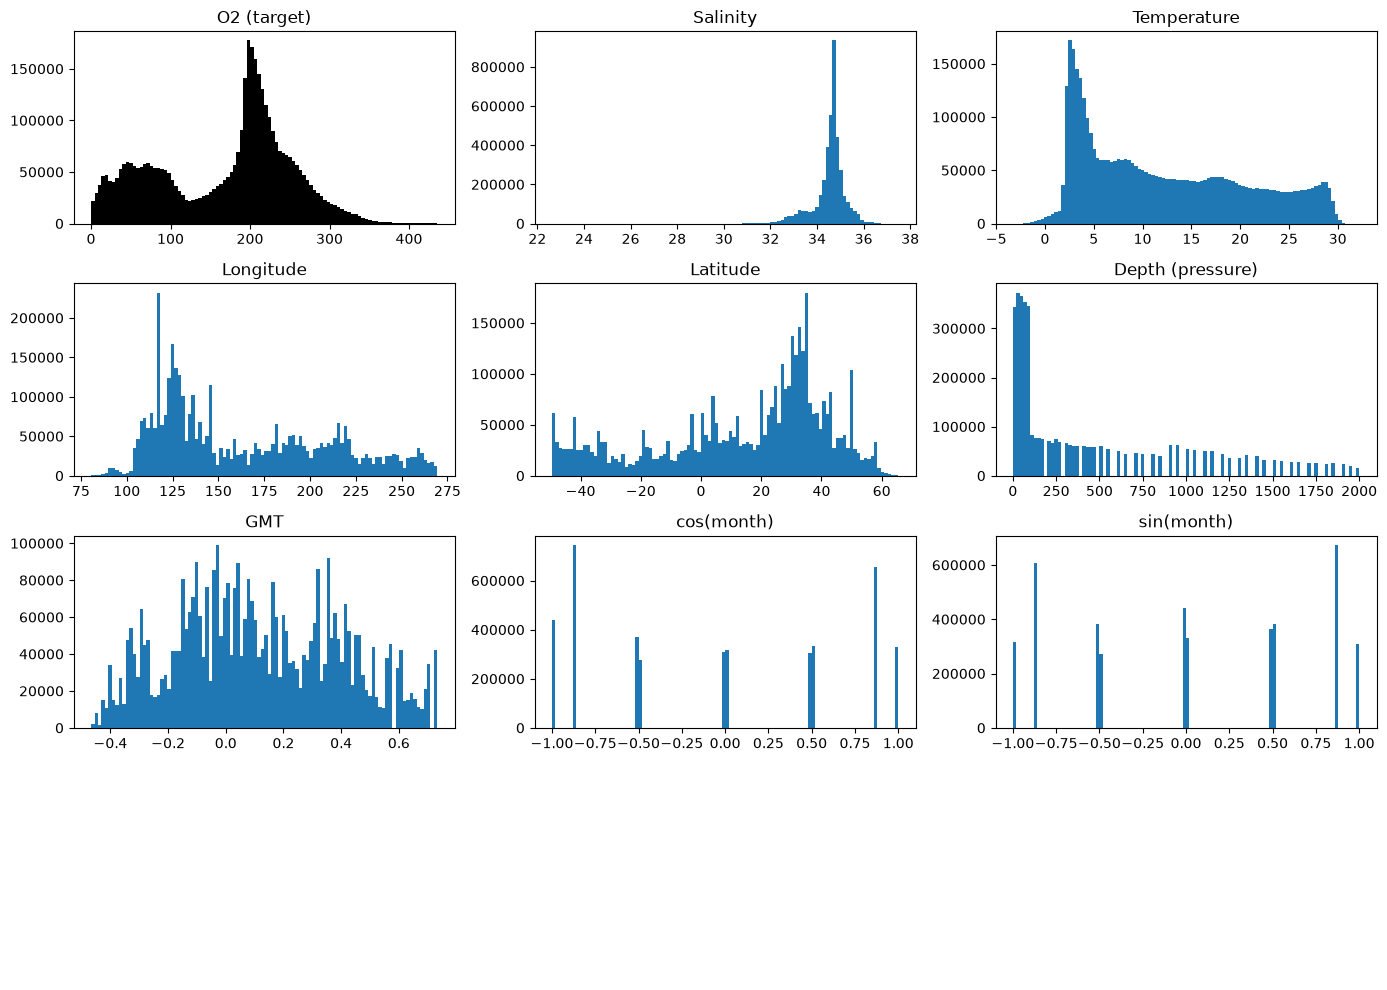

In [10]:
if selection[4]=='6':
    feature_names = ['Salinity', 'Temperature', 'Longitude', 'Latitude', 'Depth (pressure)', \
                  'GMT', 'cos(month)', 'sin(month)']
elif selection[4]=='7':
    feature_names = ['S anom', 'Salinity', 'T anom', 'Temperature', 'Longitude', 'Latitude', 'Depth (pressure)', \
                  'GMT', 'cos(month)', 'sin(month)']
# raw (unstandardized) train-split values, reused by the EDA/linear-regression cells below
X_train_eda = X[ind1, :]
y_train_eda = y[ind1]

fig, axes = plt.subplots(4, 3, figsize=(14, 10))
axes = axes.ravel()
axes[0].hist(y_train_eda, bins=100, color='k')
axes[0].set_title('O2 (target)')
for i, name in enumerate(feature_names):
    axes[i+1].hist(X_train_eda[:, i], bins=100, color='tab:blue')
    axes[i+1].set_title(name)
for ax in axes[len(feature_names)+1:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'Fig_EDA_distributions_v{ver}.pdf')
plt.show()

,Salinity,Temperature,Longitude,Latitude,Depth (pressure),GMT,cos(month),sin(month),O2
Salinity,1.000,0.375,-0.007,-0.478,0.110,0.106,0.088,0.008,-0.295
Temperature,0.375,1.000,-0.177,-0.101,-0.668,-0.156,0.024,-0.034,0.369
Longitude,-0.007,-0.177,1.000,-0.355,0.054,0.269,0.059,0.000,-0.164
Latitude,-0.478,-0.101,-0.355,1.000,-0.090,-0.198,-0.097,0.017,-0.069
Depth (pressure),0.110,-0.668,0.054,-0.090,1.000,0.239,0.002,-0.007,-0.599
GMT,0.106,-0.156,0.269,-0.198,0.239,1.000,0.022,-0.035,-0.181
cos(month),0.088,0.024,0.059,-0.097,0.002,0.022,1.000,0.005,-0.009
sin(month),0.008,-0.034,0.000,0.017,-0.007,-0.035,0.005,1.000,0.036
O2,-0.295,0.369,-0.164,-0.069,-0.599,-0.181,-0.009,0.036,1.000


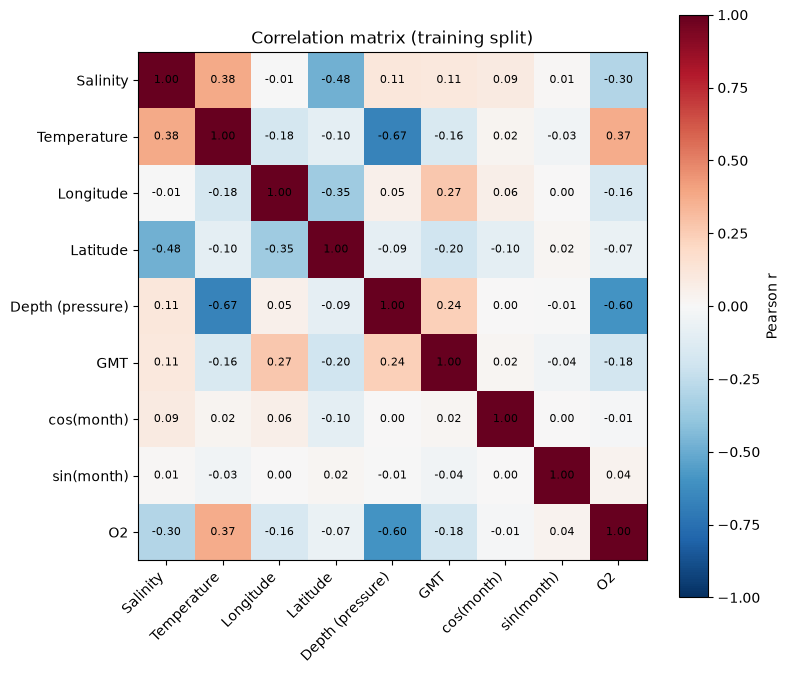

In [11]:
import pandas as pd

df_eda = pd.DataFrame(X_train_eda, columns=feature_names)
df_eda['O2'] = y_train_eda
corr = df_eda.corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Correlation matrix (training split)')
plt.tight_layout()
plt.savefig(f'Fig_EDA_correlation_v{ver}.pdf')
plt.show()

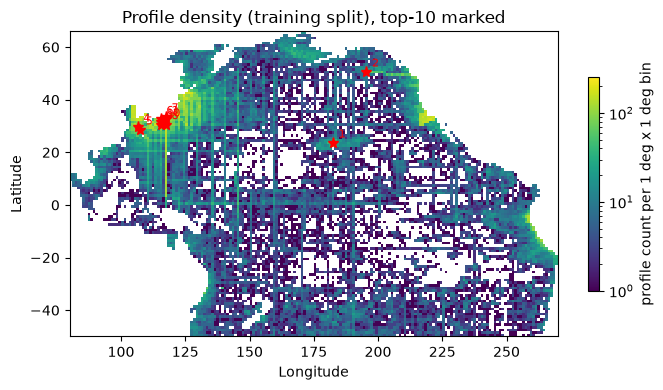

In [12]:
import matplotlib.colors as mcolors

lon_idx = feature_names.index('Longitude')
lat_idx = feature_names.index('Latitude')
lon_train = X_train_eda[:, lon_idx]
lat_train = X_train_eda[:, lat_idx]
tt1_train = tt1z[ind1]

lon_bins = np.arange(np.floor(lon_train.min()), np.ceil(lon_train.max())+1, 1)
lat_bins = np.arange(np.floor(lat_train.min()), np.ceil(lat_train.max())+1, 1)
H, xedges, yedges = np.histogram2d(lon_train, lat_train, bins=[lon_bins, lat_bins])

# profile density: dedupe repeated depth levels at the same lon/lat/year-month (same tt1 value)
# so each profile (cast) is counted once, regardless of how many depth levels it has
profile_keys = np.stack([lon_train, lat_train, tt1_train], axis=1)
_, unique_rows = np.unique(profile_keys, axis=0, return_index=True)
Hp, _, _ = np.histogram2d(lon_train[unique_rows], lat_train[unique_rows], bins=[lon_bins, lat_bins])

# top-10 highest profile-density grid cells; reused below for the map markers and
# in the next cell for the tabulated DataFrame, so both stay in sync
top10_ii, top10_jj = np.unravel_index(np.argsort(Hp.ravel())[::-1][:10], Hp.shape)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.pcolormesh(xedges, yedges, Hp.T, norm=mcolors.LogNorm(vmin=1, vmax=Hp.max()), cmap='viridis')
for rank, (i, j) in enumerate(zip(top10_ii, top10_jj), 1):
    lon_c = 0.5*(xedges[i] + xedges[i+1])
    lat_c = 0.5*(yedges[j] + yedges[j+1])
    ax.plot(lon_c, lat_c, '*', color='r', markersize=8)
    ax.annotate(str(rank), (lon_c, lat_c), textcoords='offset points', xytext=(4, 4), color='r', fontsize=8)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Profile density (training split), top-10 marked')
fig.colorbar(im, ax=ax, label='profile count per 1 deg x 1 deg bin',shrink=.7)
plt.tight_layout()
plt.savefig(f'Fig_EDA_profile_density_v{ver}.pdf')
plt.show()

In [13]:
# top-10 highest profile-density 1deg x 1deg grid cells (training split), kept as a DataFrame
# for later reference (ii/jj computed above, alongside the map markers). profile_count treats
# repeated depth levels at the same lon/lat/year/month as a single profile; count is the raw
# sample count (one entry per depth level), kept alongside for comparison.
top10 = pd.DataFrame({
    'rank': np.arange(1, 11),
    'lon_min': xedges[top10_ii],
    'lon_max': xedges[top10_ii+1],
    'lat_min': yedges[top10_jj],
    'lat_max': yedges[top10_jj+1],
    'profile_count': Hp[top10_ii, top10_jj].astype(int),
    'count': H[top10_ii, top10_jj].astype(int),
})
display(top10)

,rank,lon_min,lon_max,lat_min,lat_max,profile_count,count
0,1,182.0,183.0,23.0,24.0,254,16319
1,2,195.0,196.0,50.0,51.0,232,12094
2,3,117.0,118.0,32.0,33.0,211,10829
3,4,106.0,107.0,29.0,30.0,206,3893
4,5,107.0,108.0,28.0,29.0,206,8136
5,6,115.0,116.0,32.0,33.0,202,9774
6,7,117.0,118.0,33.0,34.0,201,10267
7,8,117.0,118.0,30.0,31.0,198,9929
8,9,115.0,116.0,30.0,31.0,197,9362
9,10,115.0,116.0,31.0,32.0,194,9087


In [14]:
# Station identification, by basin. Each basin maps a station name to one or
# more rows of `top10` (selected by rank, 1-indexed) that get combined into a
# single sample mask, mirroring how BATS was originally identified. The mask
# for each station is the union of its constituent grid cells' exact lon/lat
# boxes (not a bounding rectangle), so this is robust even if the cells for a
# station aren't arranged as a simple rectangle.
#
# BATS (Bermuda Atlantic Time-series Study), Atlantic: the two grid cells at
# lon [275,276) (adjacent lat bins [31,32) and [32,33)). Selected by lon
# identity rather than table position, since profile-count ranking (top10's
# sort order) doesn't always put both BATS cells first.
#
# HOT (Hawaii Ocean Time-series) and OSP (Ocean Station Papa), Pacific:
# identified by rank position in `top10` -- HOT = ranks 1-3 combined, OSP =
# rank 5 alone. Ranks are density-based, not fixed lon/lat, so revisit these
# if the input data changes enough to reorder the top10 table.
#
# Basins without a station definition here are skipped (no station-level
# analysis yet); this replaces an earlier version of this cell that used a
# bare `continue` outside of a loop, which is a SyntaxError and crashed this
# cell (and everything downstream that depends on it) for any non-Atlantic
# basin.
if selection[2] == '1':
    station_rows = {'BATS': top10[top10['lon_min'] == 275]}
elif selection[2] == '2':
    station_rows = {
        'HOT': top10[top10['rank'].isin([1])],
        'OSP': top10[top10['rank'] == 2],
    }
else:
    print(f"No station definitions yet for basin '{basin[int(selection[2])-1]}'; skipping station-level analysis.")
    station_rows = {}

lon_all = xx1[z_mask]
lat_all = yy1[z_mask]

def _rows_to_mask(rows):
    mask = np.zeros(lon_all.shape, dtype=bool)
    for _, r in rows.iterrows():
        mask |= (lon_all >= r['lon_min']) & (lon_all < r['lon_max']) & \
                (lat_all >= r['lat_min']) & (lat_all < r['lat_max'])
    return mask

stations = {}
for name, rows in station_rows.items():
    region_mask_all = _rows_to_mask(rows)
    stations[name] = {
        'lon': (rows['lon_min'].min(), rows['lon_max'].max()),
        'lat': (rows['lat_min'].min(), rows['lat_max'].max()),
        'mask_all': region_mask_all,
        'train': region_mask_all[ind1],
        'test': region_mask_all[ind],
    }
    st = stations[name]
    print(f"{name}: lon {st['lon']}, lat {st['lat']}, "
          f"sample count -- train: {np.sum(st['train'])}, test: {np.sum(st['test'])}")

# kept for the BATS case study section below (Atlantic-only), so it doesn't
# need to be rewritten to index into `stations` directly
if 'BATS' in stations:
    region_lon = stations['BATS']['lon']
    region_lat = stations['BATS']['lat']
    region_mask_all = stations['BATS']['mask_all']
    region_train = stations['BATS']['train']
    region_test = stations['BATS']['test']

HOT: lon (np.float64(182.0), np.float64(183.0)), lat (np.float64(23.0), np.float64(24.0)), sample count -- train: 16319, test: 3570
OSP: lon (np.float64(195.0), np.float64(196.0)), lat (np.float64(50.0), np.float64(51.0)), sample count -- train: 12094, test: 3440


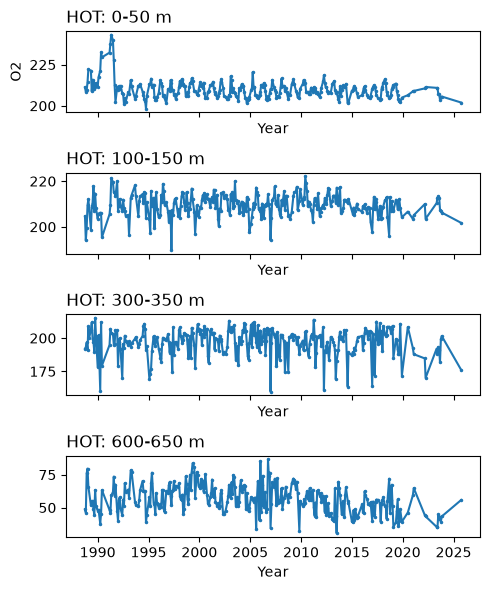

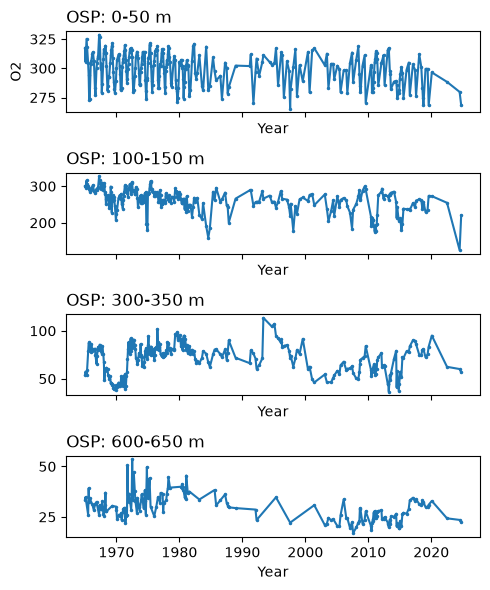

In [15]:
# O2 time series at each identified station, for 3 depth bins. Uses the full
# time record (train+test years, i.e. the region mask over the full
# z_mask-filtered arrays) rather than the train-only split, since this is an
# exploratory look at the raw data rather than a leakage-sensitive model fit.
# Multiple depth levels can fall in the same 50m bin, so values are averaged
# per unique timestamp (tt1) to give one point per profile date.
depth_bins = [(0, 50), (100, 150), (300, 350), [600,650]]

depth_z = zz1[z_mask]
o2_z = doa1[z_mask]

for name, st in stations.items():
    fig, axes = plt.subplots(len(depth_bins),1, figsize=(5,6), sharex=True)
    for col, (dmin, dmax) in enumerate(depth_bins):
        cell_mask = st['mask_all'] & (depth_z >= dmin) & (depth_z < dmax)
        ts = pd.DataFrame({'t': tt1z[cell_mask], 'o2': o2_z[cell_mask]}).groupby('t')['o2'].mean().reset_index()
        year = ts['t']/12 + 1965

        ax = axes[col]
        ax.plot(year, ts['o2'], '.-', markersize=3)
        ax.set_title(f'{name}: {dmin}-{dmax} m',loc='left')
        ax.set_xlabel('Year')
        if col == 0:
            ax.set_ylabel('O2')
    plt.tight_layout()
    plt.savefig(f'Fig_station_timeseries_{name}_v{ver}.pdf')
    plt.show()

In [16]:
# accumulates every model's held-out test-set metrics computed in this
# notebook run, so a single results table can be built per basin (see the
# summary cell at the end) and concatenated across basins by run_all_basins.py
results = []

def log_result(model, config, R2, RMSE, r=None):
    results.append({
        'ver': ver,
        'basin': basin[int(selection[2]) - 1],
        'model': model,
        'config': config,
        'R2': R2,
        'RMSE': RMSE,
        'r': r,
    })

### Multiple linear regression baseline
- OLS fit on the same 8 predictors, in physical (unstandardized) units, as a simple interpretable baseline for the nonlinear MLP models below.
- Uses the same outer train/test split as the MLP experiments (`ind1`/`ind` masks), so R2/RMSE are directly comparable.

In [17]:
from sklearn.linear_model import LinearRegression

X_test_lr = X[ind, :]
y_test_lr = y[ind]

lr_model = LinearRegression()
lr_model.fit(X_train_eda, y_train_eda)

y_est_lr = lr_model.predict(X_test_lr)
R2_lr = r2_score(y_test_lr, y_est_lr)
RMSE_lr = np.sqrt(np.mean((y_est_lr - y_test_lr)**2))
print(f'Linear Regression: R2={R2_lr:.4f}  RMSE={RMSE_lr:.4f}')
for name, coef in zip(feature_names, lr_model.coef_):
    print(f'  {name:>18s}: {coef: .5f}')
log_result('Linear Regression', 'full features', R2_lr, RMSE_lr)

Linear Regression: R2=0.4215  RMSE=63.1201
            Salinity: -9.13420
         Temperature: -1.37274
           Longitude: -0.44051
            Latitude: -0.79347
    Depth (pressure): -0.11171
                 GMT: -5.04196
          cos(month): -1.12806
          sin(month):  3.83050


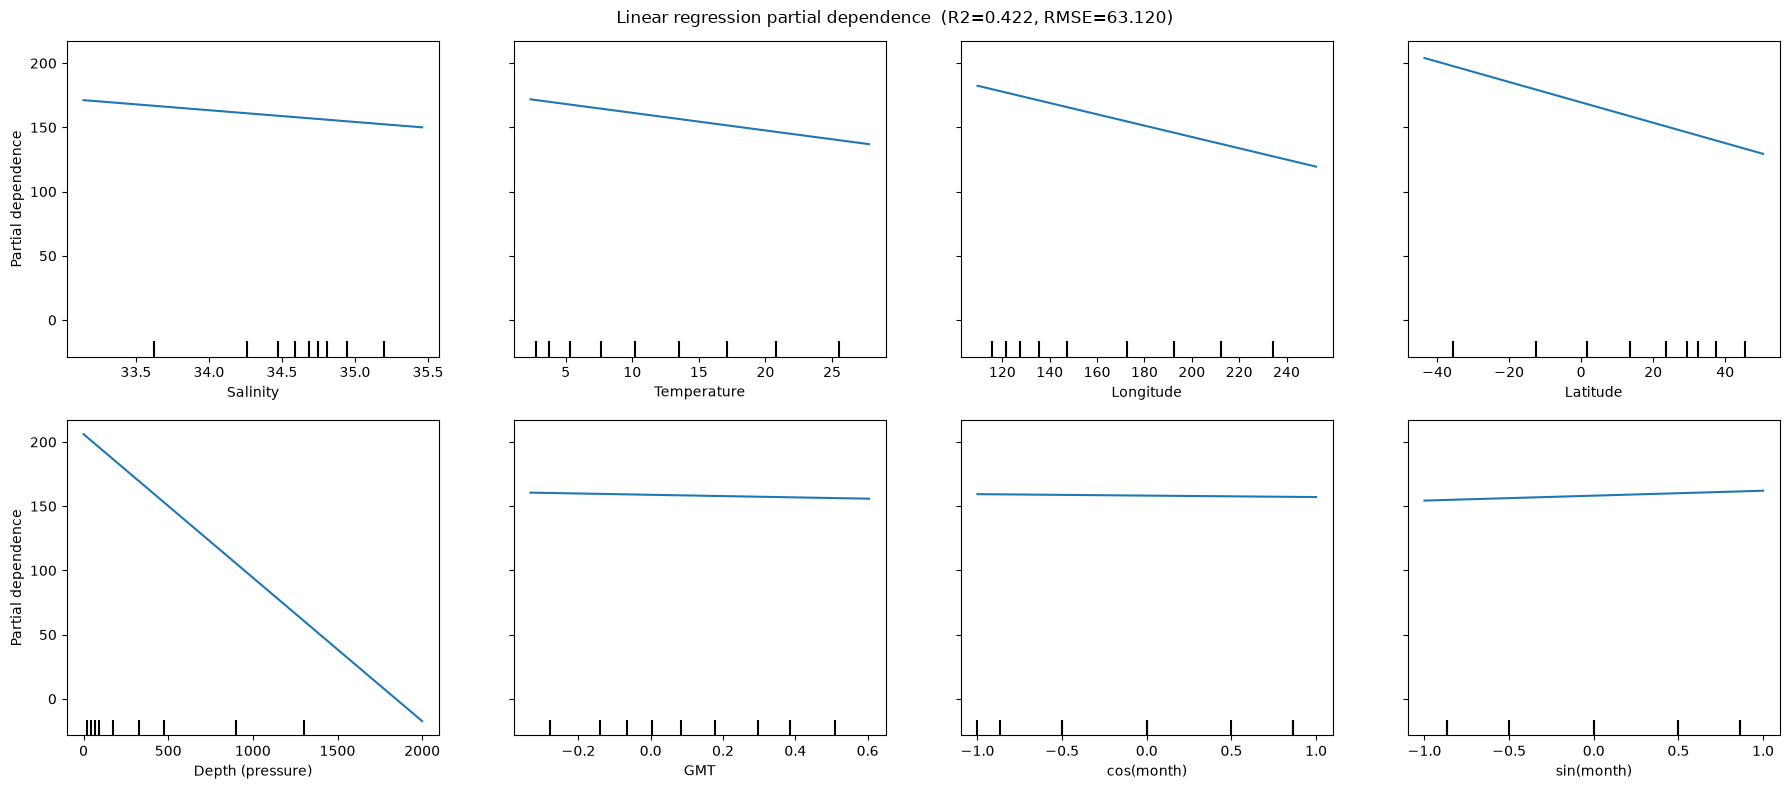

In [18]:
from sklearn.inspection import PartialDependenceDisplay

# PD is estimated by averaging predictions over a background sample; a random
# subsample is enough here since the model is linear (the marginal slope doesn't
# depend on sample size) and keeps this fast on ~2.8M training rows
rng = np.random.default_rng(seed)
pd_idx = rng.choice(X_train_eda.shape[0], size=min(20000, X_train_eda.shape[0]), replace=False)

fig, ax = plt.subplots(figsize=(18, 8))
disp = PartialDependenceDisplay.from_estimator(
    lr_model, X_train_eda[pd_idx], features=range(len(feature_names)),
    feature_names=feature_names, n_cols=4, ax=ax,
)
disp.figure_.suptitle(f'Linear regression partial dependence  (R2={R2_lr:.3f}, RMSE={RMSE_lr:.3f})')
plt.tight_layout()
plt.savefig(f'Fig_EDA_LinearRegression_PartialDependence_v{ver}.pdf')
plt.show()

## PyTorch MLP model
- Plain fully-connected network: `Linear -> ReLU` per hidden layer, single linear output unit.
- `weight_decay` in the Adam optimizer plays the same role as sklearn's `alpha` (L2 regularization).
- Folds are trained **sequentially** on the single shared GPU — each fit already saturates the GPU internally, and running several fits concurrently via multiprocessing would just contend for the same device.
- This cell configures the MLP model with high flexibility
- This cell trains the MLP model with dynamic plotting of the learning curve

In [19]:
class MLP(nn.Module):
    def __init__(self, n_in, hidden_layer_sizes):
        super().__init__()
        layers = []
        n_prev = n_in
        for h in hidden_layer_sizes:
            layers.append(nn.Linear(n_prev, h))
            layers.append(nn.ReLU())
            n_prev = h
        layers.append(nn.Linear(n_prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def fit_mlp(X_tr, y_tr, hidden_layer_sizes, optim='SGD', weight_decay=0.01, \
            lr=1e-3, epochs=200, batch_size=10000, momentum = 0.9, nesterov = False, \
            betas=(0.9, 0.999), verbose=False, X_val=None, y_val=None, plot_live=False, \
            early_stopping=False, patience=50):
    # data is small enough to live on the GPU whole; mini-batching is done by
    # indexing GPU-resident tensors directly rather than via DataLoader, since
    # DataLoader's per-batch Python/host-transfer overhead dominates for a model
    # this small and makes the GPU no faster than plain CPU
    torch.manual_seed(seed)
    model = MLP(X_tr.shape[1], hidden_layer_sizes).to(device)
    if optim == 'SGD':
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, nesterov=nesterov, weight_decay=weight_decay)
    elif optim == 'Adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr, betas=betas, eps=1e-8, weight_decay=weight_decay)
    elif optim == 'AdamW':
        opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=betas, eps=1e-8, weight_decay=weight_decay)
    #
    loss_fn = nn.MSELoss()
    #
    X_t = torch.tensor(X_tr, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_tr, dtype=torch.float32, device=device)
    n = X_t.shape[0]
    #
    # X_val/y_val are optional: pass a held-out split to also track validation
    # loss each epoch (e.g. for the final retrain, using the outer test set)
    has_val = X_val is not None
    if has_val:
        X_v = torch.tensor(X_val, dtype=torch.float32, device=device)
        y_v = torch.tensor(y_val, dtype=torch.float32, device=device)
    #
    if early_stopping and not has_val:
        raise ValueError('early_stopping requires X_val/y_val to be provided')
    #
    train_losses = []
    val_losses = []
    # early stopping: track the best (lowest) validation loss seen so far and its
    # epoch/weights; once `patience` epochs pass with no improvement, stop and roll
    # the model back to those best weights rather than keeping the final (possibly
    # overfit) ones
    best_val_loss = np.inf
    best_epoch = None
    best_state = None
    epochs_no_improve = 0
    # plot_live requires has_val (nothing to plot against otherwise) and redraws
    # a single figure in place every 10 epochs, notebook-only (uses IPython display)
    if plot_live and has_val:
        fig, ax = plt.subplots(figsize=(6, 4))
    #
    model.train()
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            xb, yb = X_t[idx], y_t[idx]
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()*xb.size(0)
        train_losses.append(epoch_loss/n)
        # evaluate validation loss on the full held-out split (no mini-batching needed for eval)
        if has_val:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(X_v), y_v).item()
            val_losses.append(val_loss)
            if early_stopping:
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_epoch = epoch
                    best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
        if plot_live and has_val and ((epoch + 1) % 10 == 0 or epoch == epochs - 1):
            # display intermediate results
            clear_output(wait=True)
            ax.clear()
            ax.plot(np.arange(0, epoch+1, 1), train_losses, '-', color='b', label='Train')
            ax.plot(np.arange(0, epoch+1, 1), val_losses, '--', color='r', label='Valid')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Loss')
            ax.legend()
            display(fig)
            print(f'Epoch {epoch+1}/{epochs}  train loss={epoch_loss/n:.4f}')
        elif verbose and (epoch % 20 == 0 or epoch == epochs-1):
            msg = f'  epoch {epoch:4d}  train MSE = {epoch_loss/n:.5f}'
            if has_val:
                msg += f'  val MSE = {val_loss:.5f}'
            print(msg)
        if early_stopping and epochs_no_improve >= patience:
            if verbose:
                print(f'  early stopping at epoch {epoch+1} '
                      f'(best epoch {best_epoch+1}, best val MSE = {best_val_loss:.5f})')
            break
    if early_stopping and best_state is not None:
        model.load_state_dict(best_state)
    model.best_epoch = best_epoch
    if plot_live and has_val:
        plt.close(fig)
    model.train_losses = train_losses
    model.val_losses = val_losses
    return model


@torch.no_grad()
def predict_mlp(model, X):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    return model(X_t).cpu().numpy()

### AdamW with early stopping (patience=50)
- Same configuration as the AdamW run above, but training stops once validation loss hasn't improved for 50 consecutive epochs, and the returned model's weights are rolled back to the best (lowest validation-loss) epoch rather than the final one.

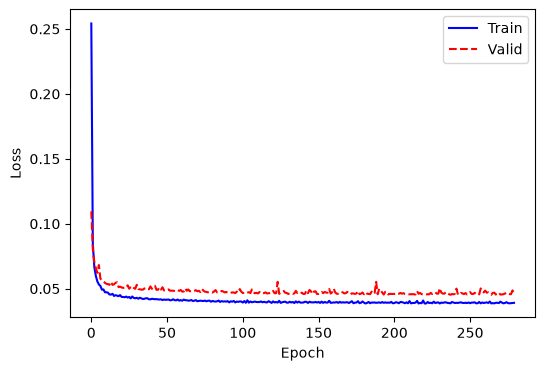

Epoch 280/500  train loss=0.0391
  epoch  280  train MSE = 0.03991  val MSE = 0.04566
  early stopping at epoch 288 (best epoch 238, best val MSE = 0.04530)
R2=0.9536  RMSE=17.8797
Best epoch (restored): 238 of 288 run


In [20]:
# single model training with all training data, with early stopping (patience=50)
#
model = fit_mlp(X_train, y_train, [64,64], optim='AdamW', weight_decay = 0.1, lr=0.01, \
                betas=(0.9,0.999), batch_size=100000, epochs=500, verbose=True, X_val = X_test, y_val = y_test, \
                plot_live=True, early_stopping=True, patience=50)
y_est = predict_mlp(model, X_test)
#
R2 = r2_score(y_test, y_est)
RMSE = np.sqrt(np.mean((y_est-y_test)**2))*ystd
print(f'R2={R2:.4f}  RMSE={RMSE:.4f}')
if model.best_epoch is not None:
    print(f'Best epoch (restored): {model.best_epoch+1} of {len(model.val_losses)} run')
log_result('AdamW (early stop, patience=50)', 'lr=0.01, wd=0.1', R2, RMSE)

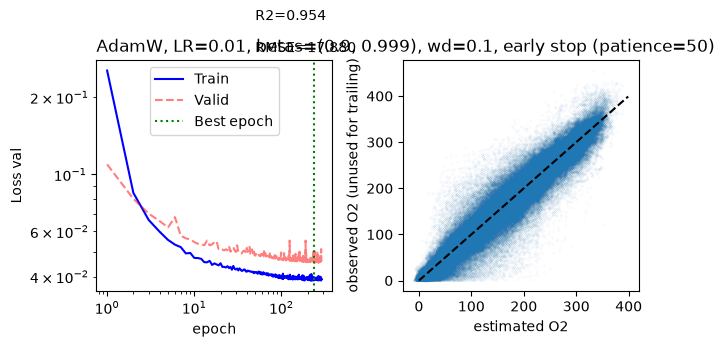

In [21]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
plt.subplots_adjust(wspace=.3)

ep=np.arange(1,len(model.train_losses)+1,1)
ax[0].loglog(ep,model.train_losses, '-', color='b', label='Train')
ax[0].loglog(ep,model.val_losses, '--', color='r', label='Valid',alpha=.5)
if model.best_epoch is not None:
    ax[0].axvline(model.best_epoch+1, color='g', linestyle=':', label='Best epoch')
ax[0].text(50,.4,f'R2={R2:.3f}')
ax[0].text(50,.3,f'RMSE={RMSE:.3f}')
ax[0].set_title('AdamW, LR=0.01, betas=(0.9, 0.999), wd=0.1, early stop (patience=50)',loc='left')
ax[0].legend()
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Loss val')

ax[1].plot(y_est*ystd+ym,y_test*ystd+ym,'.',markersize=.1,alpha=.5)
ax[1].plot(np.arange(0,400,1),np.arange(0,400,1),'--',color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2 (unused for trailing)')

plt.savefig(f'Fig_AdamW_earlystop_v{ver}.pdf',bbox_inches='tight')

In [ ]:
plt.hist(y_test*ystd+ym)

In [ ]:
# explicitly pin down which trained model feeds the gridded reconstruction below,
# so it stays unambiguous even if the optimizer-sweep cells above are edited,
# reordered, or re-run individually later
recon_model = model  # AdamW, weight_decay=0.1, lr=0.01, early stopping (patience=50)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Run prediction
out = predict_mlp(recon_model, X_test)

# Undo normalization
o2est  = out * ystd + ym
o2test = y_test * ystd + ym

# Scatter plot
plt.figure(figsize=(5,5))
plt.plot(o2est, o2test, 'k.', markersize=0.1,alpha=.3,rasterized=True)
plt.plot([0, 400], [0, 400], 'r--')
plt.xlabel('O2 prediction, micro-mol/kg')
plt.ylabel('O2 test data, micro-mol/kg')
plt.title(f'{basin[int(selection[2])-1]}: Oxygen Prediction vs Test Data',loc='left')
xmin = np.percentile(o2est,2)
ymax = np.percentile(o2test,98)

# Metrics
Rval  = np.corrcoef(o2est, o2test)[0,1]
R2    = Rval**2
RMSE  = np.sqrt(mean_squared_error(o2test, o2est))

print(f"R2   = {R2:.4f}")
print(f"RMSE = {RMSE:.4f} micro-mol/kg")
log_result('Random Forest (validation)', 'GPU cuML RF, n_estimators=500', R2, RMSE, r=Rval)
#
plt.text(xmin,ymax,f'R2 = {R2:.3f}')
plt.text(xmin,ymax*.9,f'RMSE = {RMSE:.3f}')
plt.savefig(f'Fig_MLP_validation_simple_v{ver}.pdf')
#
plt.show()

### Training vs validation performance
Contrasts R2/RMSE on the training partition (`X_train`/`y_train`) against the held-out validation set evaluated above. A training score much higher than validation indicates overfitting.

In [ ]:
# Training-set predictions, to contrast against the held-out validation
# (X_test) metrics computed above -- a large train/validation gap would
# indicate overfitting.
out_train   = predict_mlp(model, X_train)
o2est_train = out_train * ystd + ym
o2train     = y_train * ystd + ym

Rval_train = np.corrcoef(o2est_train, o2train)[0, 1]
R2_train   = Rval_train**2
RMSE_train = np.sqrt(mean_squared_error(o2train, o2est_train))

print(f"Training:   R2 = {R2_train:.4f}   RMSE = {RMSE_train:.4f} micro-mol/kg")
print(f"Validation: R2 = {R2:.4f}   RMSE = {RMSE:.4f} micro-mol/kg")

log_result('Random Forest (train)', 'GPU cuML RF, n_estimators=500', R2_train, RMSE_train, r=Rval_train)

# single panel, R2 and RMSE on twin y-axes (different units/scales) so both
# metrics are visible together rather than as two separate subplots
x = np.arange(2)
width = 0.3

fig, ax1 = plt.subplots(figsize=(5, 4))
ax2 = ax1.twinx()

bars_r2 = ax1.bar(x - width/2, [R2_train, R2], width, color='tab:blue', label='R2')
bars_rmse = ax2.bar(x + width/2, [RMSE_train, RMSE], width, color='tab:orange', label='RMSE')

ax1.bar_label(bars_r2, fmt='%.3f', padding=3, color='tab:blue')
ax2.bar_label(bars_rmse, fmt='%.2f', padding=3, color='tab:orange')

ax1.set_xticks(x)
ax1.set_xticklabels(['Train', 'Validation'])
ax1.set_ylabel('R2', color='tab:blue')
ax1.set_ylim(0.7, 1)
ax2.set_ylim(10, 20)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2.set_ylabel('RMSE, micro-mol/kg', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_title('Train vs validation: R2 and RMSE')
ax1.legend([bars_r2, bars_rmse], ['R2', 'RMSE'], loc='upper right')

plt.tight_layout()
plt.savefig(f'Fig_RF_train_vs_validation_v{ver}.pdf')
plt.show()

## Inference: gridded O2 map reconstruction
Reconstructs a full basin O2 field (all EN4 grid points, `year_start`-`year_end`, 0-`recon_max_depth` m) using the PyTorch MLP model (`recon_model`, pinned above to the AdamW + early-stopping run) and normalization stats (`Xm`/`Xstd`/`ym`/`ystd`) already fit above -- no checkpoint save/reload needed since this all runs in one notebook session.

Ported directly from `GTMLO2_cuML_RF_single.ipynb`'s reconstruction section -- feature construction and basin masking (EN4 T/S -> lon/lat/depth/GMT/cos/sin(month) predictors, longitude shift-and-wrap, polar-coordinate substitution for the southern/arctic basins, 3D basin masking restricted to this basin's `bindex`) and basin-column-restricted interpolation are unchanged; the only difference is the model call itself, `predict_mlp(recon_model, ...)` in place of `regr.predict(...)`. Runs single-process (no `ProcessPoolExecutor`) -- `predict_mlp` already GPU-batches per call, and file I/O for one basin's years is the dominant cost either way.

Note: `recon_max_depth` is a separate variable from the `max_depth` defined near the top of this notebook (that one is the training-sample depth cutoff, 5500 m) -- kept distinct deliberately to avoid shadowing it.

In [ ]:
# Reconstruction configuration
year_start = 1965
year_end = 2025
recon_max_depth = 2000.  # deepest EN4 depth level (m) to reconstruct -- matches the raw WOD
                          # O2 observations training targets are drawn from (0-1800m); anything
                          # deeper is extrapolation with no real label to learn from

# reuses the SST file already maintained alongside o2_project_torch.ipynb rather
# than duplicating it under this project

In [ ]:
# EN4 grid, 3D basin mask, and static (lon/lat/depth) predictor features for the
# reconstruction grid. Inlined here (mirroring o2_project_torch.py's
# build_basin_mask_3d / build_lonlat_features / build_column_index) since this
# notebook doesn't depend on an external module.
BINDEX = [1, 2, 3, 10, 11, 4, 5, 6, 7, 8, 9, 12, 53]
recon_bid = int(selection[2])
recon_bindex = BINDEX[recon_bid - 1]

if selection[3]=='4':
    en4_dir = f'{data_root}/EN4/C14/'
    dbase = 'EN4_C14_180x360_'
    print('inference T/S data is EN4')
elif selection[3]=='5':
    en4_dir = f'{data_root}/IAP/IAP_202608/'
    dbase = 'IAP_180x360_'
    print('inference T/S data is IAP')
#
ds0 = xr.open_dataset(f'{en4_dir}{dbase}196501.nc')
Zr = ds0.depth.sel(depth=slice(0, recon_max_depth)).to_numpy()
lon_grid = ds0.lon.to_numpy()
lat_grid = ds0.lat.to_numpy()
ds0.close()
Nzr, Nyr, Nxr = np.size(Zr), np.size(lat_grid), np.size(lon_grid)
print(f'reconstruction grid: Nz={Nzr} Ny={Nyr} Nx={Nxr}')

# basin mask: surface (depth=0) basin id (with the Indian Ocean's 56->3 remap)
# tiled to depth, kept only where the depth-specific mask is nonzero (i.e. the
# water column actually extends to that depth)
dsm = xr.open_dataset(f'{data_root}/WOD18/basin_mask_01.nc')
mask2d = dsm.basin_mask.sel(depth=0).to_numpy()[np.newaxis, :, :]
mask2d = np.where(mask2d == 56, 3, mask2d)
mask3d = np.tile(mask2d, [Nzr, 1, 1])
depth_mask = dsm.basin_mask.sel(depth=Zr).to_numpy()
basin_mask3d = np.where(depth_mask == 0, 0, mask3d)
dsm.close()

zi, yi, xi = np.where(basin_mask3d == recon_bindex)
print(f'{zi.size} in-basin (depth,lat,lon) grid points')

# restrict interpolation to the basin's unique lat/lon columns instead of the
# full grid -- a typical basin footprint is a small fraction of Ny x Nx
cols, col_of_point = np.unique(np.stack([yi, xi], axis=1), axis=0, return_inverse=True)
uy, ux = cols[:, 0], cols[:, 1]
print(f'{uy.size} unique basin lat/lon columns (of {Nyr * Nxr} total)')

# lon/lat predictor features: shift-and-wrap longitude by default, or the
# polar-coordinate substitution used for the southern/arctic basins -- matches
# the training-data convention (o2_preproc_v2026.ipynb)
xa0 = lon_grid - 20
xalt = np.where(xa0 < 0, xa0 + 360, xa0)
lon_feat2d, lat_feat2d = np.meshgrid(xalt, lat_grid)
if recon_bid == 4:
    lon_feat2d, lat_feat2d = (lat_feat2d + 90) * np.cos(np.deg2rad(lon_feat2d)), \
                             (lat_feat2d + 90) * np.sin(np.deg2rad(lon_feat2d))
elif recon_bid == 5:
    lon_feat2d, lat_feat2d = (-lat_feat2d + 90) * np.cos(np.deg2rad(lon_feat2d)), \
                             (-lat_feat2d + 90) * np.sin(np.deg2rad(lon_feat2d))

lon_feat = lon_feat2d[yi, xi]
lat_feat = lat_feat2d[yi, xi]
depth_feat = Zr[zi]

dsg = xr.open_dataset(sst_path)
GMT_recon = dsg.SST.sel(time=slice(f'{year_start}-01', f'{year_end}-12')).to_numpy()
dsg.close()

### Reconstruction loop
For each year/month: load+interpolate `so`/`thetao` restricted to the basin's lat/lon columns, build the same 8 predictors used in training (S, T, lon, lat, depth, GMT, cos(month), sin(month)), normalize with `Xm`/`Xstd`, predict with `recon_model` (via `predict_mlp`), and un-normalize with `ystd`/`ym`. Writes one per-year NetCDF to `dirout` (the temp-file directory already defined near the top of this notebook).

In [ ]:
if selection[4] != '6':
    raise NotImplementedError('Reconstruction predictor order below matches only selection[4]==6 '
                               '(S, T, lon, lat, depth, GMT, cos(month), sin(month)); '
                               'port the other selection[4] branches from o2_project.py if needed.')

mon = ["%.2d" % i for i in np.arange(1, 13, 1)]
yrs_recon = np.arange(year_start, year_end + 1)
uy_da = xr.DataArray(uy, dims='pts')
ux_da = xr.DataArray(ux, dims='pts')

for year in yrs_recon:
    out_grid = np.full((12, Nzr, Nyr, Nxr), np.nan, dtype=np.float32)
    for m in range(12):
        fpath = f'{en4_dir}{dbase}{year}{mon[m]}.nc'
        if not os.path.exists(fpath):
            print(f'  missing {fpath}, skipping')
            continue
        dc = xr.open_dataset(fpath)
        so_cols = dc.so.isel(lat=uy_da, lon=ux_da) \
            .interp(depth=Zr).transpose(..., 'depth', 'pts').to_numpy().squeeze().astype(np.float32)
        th_cols = dc.thetao.isel(lat=uy_da, lon=ux_da) \
            .interp(depth=Zr).transpose(..., 'depth', 'pts').to_numpy().squeeze().astype(np.float32)
        dc.close()

        it = m + (year - year_start) * 12

        so_pts = so_cols[zi, col_of_point]
        th_pts = th_cols[zi, col_of_point]
        valid = ~(np.isnan(so_pts) | np.isnan(th_pts))
        if not np.any(valid):
            continue

        n_valid = int(np.sum(valid))
        Xr = np.array([
            so_pts[valid], th_pts[valid],
            lon_feat[valid], lat_feat[valid], depth_feat[valid],
            np.full(n_valid, GMT_recon[it]),
            np.full(n_valid, np.cos(2 * np.pi * m / 12)),
            np.full(n_valid, np.sin(2 * np.pi * m / 12)),
        ], dtype=np.float32).T
        Xr_norm = ((Xr - Xm) / Xstd).astype(np.float32)
        preds = predict_mlp(recon_model, Xr_norm) * ystd + ym
        out_grid[m, zi[valid], yi[valid], xi[valid]] = preds

    t = np.arange(f'{year}-01', f'{year + 1}-01', dtype='datetime64[M]')
    da = xr.DataArray(out_grid, name='o2est', dims=['time', 'depth', 'lat', 'lon'],
                       coords={'time': t, 'depth': Zr, 'lat': lat_grid, 'lon': lon_grid})
    outpath = f'{dirout}o2est_v{ver}_{year}.nc'
    os.system(f'rm {outpath}')
    da.to_dataset().to_netcdf(outpath)
    print(f'wrote {outpath}')

### Combine per-year files into the final gridded product
Uses explicit per-year filenames for the requested range only -- a wildcard glob would also pick up any other years' temp files left behind by a previous run, silently mixing vintages into the final output.

In [ ]:
year_files = [f'{dirout}o2est_v{ver}_{year}.nc' for year in yrs_recon]
ds_all = xr.open_mfdataset(year_files)
finalpath = f'{dirfin}O2map_v{ver}.nc'
ds_all.to_netcdf(finalpath)
print(f'wrote {finalpath}')

### Station-level model evaluation
Applies the reconstructed gridded product (`ds_all`, written above) at the long-term time-series stations identified earlier, at a handful of constant depths, over the full time record -- observed (raw WOD profile data) vs. the gridded reconstruction, with per-station/depth R2 and RMSE logged into the results table. Using the actual gridded product (rather than raw point predictions on the original irregular profile locations) checks the fidelity of the final delivered map, including any effect of the 1x1 degree binning/averaging.

Uses its own `recon_depth_bins` (constant depths, for exact `.sel(depth=d, method='nearest')` lookups against the gridded product) rather than the `depth_bins` *ranges* defined earlier for the raw station time-series plot -- the two aren't interchangeable, so they're kept as separate variables.

In [ ]:
# Station-level model evaluation, using the reconstructed gridded product
# (ds_all) rather than raw point predictions -- samples the gridded o2est at
# each station's lon/lat box and each constant depth, then compares against
# the raw observed WOD profile data at the same station/depth (same
# masks/arrays as the raw time-series cell above).
recon_depth_bins = [0, 50, 100, 200]

pred_year = ds_all.time.dt.year.values
pred_month = ds_all.time.dt.month.values
t_pred = (pred_year - year_start) * 12 + (pred_month - 1)

station_ts_by_depth = {}

for name, st in stations.items():
    lon_min, lon_max = st['lon']
    lon_min=lon_min+20-360
    lon_max=lon_max+20-360
    lat_min, lat_max = st['lat']
    lon_sel = ds_all.lon.values[(ds_all.lon.values >= lon_min) & (ds_all.lon.values < lon_max)]
    lat_sel = ds_all.lat.values[(ds_all.lat.values >= lat_min) & (ds_all.lat.values < lat_max)]
    station_grid = ds_all.o2est.sel(lon=lon_sel, lat=lat_sel)

    ts_by_depth = []
    fig, axes = plt.subplots(len(recon_depth_bins), 1, figsize=(7, 8), sharex=True)
    for row, d in enumerate(recon_depth_bins):
        pred_series = station_grid.sel(depth=d, method='nearest').mean(dim=['lon', 'lat'], skipna=True).values
        pred_df = pd.DataFrame({'t': t_pred, 'pred': pred_series}).dropna()

        cell_mask = st['mask_all'] & (depth_z == d)
        obs_df = pd.DataFrame({'t': tt1z[cell_mask], 'obs': o2_z[cell_mask]}).groupby('t')['obs'].mean().reset_index()

        # stats are computed only where both obs and the gridded reconstruction
        # exist (an inner join), but the plot below shows the gridded series
        # over its full time range -- not just the sparse months with observations
        ts = obs_df.merge(pred_df, on='t', how='inner')
        ts_by_depth.append(ts)

        r = ts['obs'].corr(ts['pred'])
        r2_station = r**2
        rmse_station = np.sqrt(np.mean((ts['pred'] - ts['obs'])**2))
        log_result('PyTorch MLP (station)', f'{name} {d}m', r2_station, rmse_station, r=r)

        pred_year_axis = pred_df['t']/12 + 1965
        obs_year_axis = obs_df['t']/12 + 1965

        ax = axes[row]
        ax.plot(pred_year_axis, pred_df['pred'], '-', color='b', linewidth=1, label='MLP prediction (gridded)')
        ax.plot(obs_year_axis, obs_df['obs'], '.', color='k', markersize=4, label='Observed')
        ax.set_title(f'{name}: {d} m', loc='left')
        ax.set_ylabel('O2')
        ax.text(0.02, 0.95, f'r={r:.2f}', transform=ax.transAxes, fontsize=8, va='top')
        if row == 0:
            ax.legend(fontsize=8)
    axes[-1].set_xlabel('Year')
    plt.tight_layout()
    plt.savefig(f'Fig_{name}_MLP_station_timeseries_v{ver}.pdf')
    plt.show()

    station_ts_by_depth[name] = ts_by_depth

if not stations:
    print('No stations defined for this basin; skipping station-level model evaluation.')

In [ ]:
# combined results table for this basin/ver (linear-regression baseline, each
# optimizer/config sweep, and station-level gridded-reconstruction evaluation)
df_results = pd.DataFrame(results)
display(df_results)
df_results.to_csv(f'Results_v{ver}.csv', index=False)